# A second AI model at Heathrow — the autoregressive rainfall generator
## Simpler than TimeGAN, and built around what rainfall actually looks like

**MSc EEDS — Imperial College London**  ·  Supervisor: Prof. C. Onof

---

## Why a second AI model

The TimeGAN notebook ended badly, and for an interesting reason. The network **mode-collapsed**: it produced almost the same four-day window every time, capped its heaviest hour at 0.9 mm against 10.8 mm observed, and left 76 % of its windows completely dry. Four training configurations did not fix it.

That failure was not bad luck. A GAN is a *competition* between two networks, and competitions can end in a stalemate where one side stops learning. It is a well-known fragility, and it has nothing to do with rainfall.

So this notebook tries a model with **no competition at all**. There is one network, one loss, and one thing to minimise — like an ordinary regression. **Mode collapse is impossible here**, because there is no adversary to collapse against.

## The idea, in one sentence

> At every hour, the model looks at the rainfall so far and answers two questions: **will it rain next hour?** and **if it does, how much?**

Then we roll it forward: sample an answer, feed it back in, ask again. Hour by hour, a whole rainfall series appears.

## Why this suits rainfall so much better

Section 2 of the TimeGAN notebook listed three properties that make rainfall hard. This model handles all three **by construction**, not by tricks:

| the difficulty | how TimeGAN dealt with it | how this model deals with it |
|---|---|---|
| 91.5 % of hours are exactly zero | a separate occurrence channel, plus a threshold we had to calibrate | a **probability of rain** — real zeros come out naturally |
| intensities span 0.1 to 48.5 mm | a log transform, and the network still capped at 0.9 mm | a **gamma distribution**, which has a heavy tail built in |
| training must not degenerate | four configurations, none of them healthy | **maximum likelihood** — a single loss, no adversary |

The gamma distribution for rainfall amounts is not my invention: it is the classical choice in stochastic weather generators, going back to Richardson (1981). What is new here is letting a neural network choose its parameters afresh at every hour, from the recent history.

| § | Content |
|---|---|
| 1 | The data (same quality control as everywhere else) |
| 2 | What the model has to output |
| 3 | Preparing the rainfall |
| 4 | The model — one GRU, three numbers |
| 5 | Training by maximum likelihood |
| 6 | Generating rainfall hour by hour |
| 6.5 | Getting the extremes right |
| 7 | The three other sources, loaded from the earlier notebooks |
| 8 | First look |
| 9 | The collapse check — does this one stay healthy? |
| 10 | The scoreboard: Bartlett–Lewis vs TimeGAN vs this model |
| 11 | Three closer looks |
| 12 | Conclusions |

## 1. The data

Identical to the Bartlett–Lewis and TimeGAN notebooks, so that all three generators are judged on exactly the same observations. The thirteen calendar months with zero rainfall are gauge failures written down as zeros, and are masked out.

In [1]:
%matplotlib inline
import warnings, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from scipy.stats import skew as scipy_skew
warnings.filterwarnings('ignore'); plt.rcParams.update({'figure.dpi':110, 'font.size':11})

SEED = 20240601
torch.manual_seed(SEED); np.random.seed(SEED)
FIG_DIR = Path('outputs/autoregressive_heathrow_v1'); FIG_DIR.mkdir(parents=True, exist_ok=True)
def show(fig, name): fig.savefig(FIG_DIR/f'{name}.png', dpi=150, bbox_inches='tight'); plt.show()

def find(rel):
    for root in ['.', '..', '../..', r'C:\Users\rajab\OneDrive\Bureau\DISSERTATION']:
        p = Path(root)/rel
        if p.exists(): return str(p.resolve())
    raise FileNotFoundError(rel)

df = pd.read_csv(find('Data/Heathrow1949-2022.csv')); df.columns = df.columns.str.strip()
df['datatime'] = pd.to_datetime(df['datatime'], format='%Y/%m/%d %H:%M')
series = pd.Series(df['Heathrow'].to_numpy(float), index=df['datatime']).sort_index()
dead_months = series.resample('MS').sum().pipe(lambda z: z[z == 0].index)
rain = series.mask(series.index.to_period('M').isin(pd.PeriodIndex(dead_months, freq='M')))

valid = rain.dropna()
print(f'Hourly values : {len(rain):,}  ({rain.index[0]:%Y} to {rain.index[-1]:%Y})')
print(f'Masked as gauge failure : {int(rain.isna().sum()):,} hours')
print(f'Annual rainfall : {valid.sum()/(len(valid)/8766):.0f} mm   |   dry hours : {(valid==0).mean()*100:.1f}%')

Hourly values : 648,672  (1949 to 2022)
Masked as gauge failure : 9,360 hours
Annual rainfall : 590 mm   |   dry hours : 91.5%


## 2. What the model has to output

The whole design rests on one observation about rainfall: **it is two different things at once**. Whether it rains is a yes/no event; how much falls is a positive number with a long tail. Trying to describe both with a single number is what made the TimeGAN intensity channel collapse.

So the model outputs a **probability of rain**, plus a description of how much rain — as **two gamma distributions rather than one**:

| output | meaning |
|---|---|
| **p** | probability that the next hour is wet |
| **w** | if it rains, is this ordinary rain or a rare heavy hour? |
| **m₁, s₁** | the ordinary kind: its average amount and variability |
| **m₂, s₂** | the rare heavy kind: same two numbers |

Using two gammas instead of one is not decoration, and it is the one place where this notebook deviates from the simplest possible design. I first built the model with a single gamma. It reproduced the record well but **stopped short of the heaviest hours** — 6.9 mm in a whole winter against 10.8 mm observed. Section 6.5 shows what I tried and why this is the version that survived.

There is also a physical reading: British rainfall is a mixture of two regimes, steady frontal rain and short convective bursts, and a two-component mixture is the classical way of writing that down.

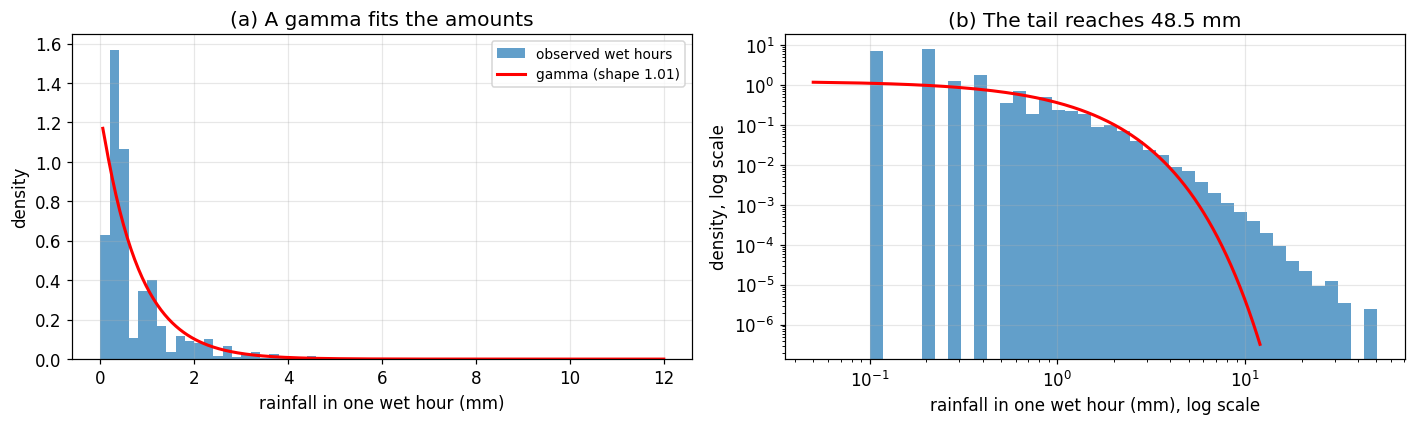

Fitted gamma shape 1.008, mean 0.795 mm  |  observed mean of wet hours 0.795 mm


In [2]:
from scipy.stats import gamma as gamma_dist
wet = valid[valid > 0].to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
# (a) the observed distribution of wet-hour amounts, with a fitted gamma on top
ax[0].hist(wet, bins=np.arange(0, 12, 0.2), density=True, color='#1f77b4', alpha=0.7, label='observed wet hours')
a, loc, scale = gamma_dist.fit(wet, floc=0)
grid = np.linspace(0.05, 12, 300)
ax[0].plot(grid, gamma_dist.pdf(grid, a, loc, scale), 'r-', lw=2, label=f'gamma (shape {a:.2f})')
ax[0].set_xlabel('rainfall in one wet hour (mm)'); ax[0].set_ylabel('density')
ax[0].set_title('(a) A gamma fits the amounts'); ax[0].legend(fontsize=9)

# (b) the same thing on a log axis, where the tail is visible
ax[1].hist(wet, bins=np.logspace(-1, 1.7, 40), density=True, color='#1f77b4', alpha=0.7)
ax[1].plot(grid, gamma_dist.pdf(grid, a, loc, scale), 'r-', lw=2)
ax[1].set_xscale('log'); ax[1].set_yscale('log')
ax[1].set_xlabel('rainfall in one wet hour (mm), log scale'); ax[1].set_ylabel('density, log scale')
ax[1].set_title(f'(b) The tail reaches {wet.max():.1f} mm')
for a_ in ax: a_.grid(alpha=0.3)
plt.tight_layout(); show(fig, '01_gamma')
print(f'Fitted gamma shape {a:.3f}, mean {a*scale:.3f} mm  |  observed mean of wet hours {wet.mean():.3f} mm')

### Reading this figure

Panel **(a)** shows the shape of the problem: most wet hours are small, and the frequency falls away smoothly. A gamma distribution — the red line — follows that shape with only two parameters.

Panel **(b)** is the same data on log axes, where the rare heavy hours become visible. This is the part TimeGAN could not produce at all: it stopped at 0.9 mm. A gamma distribution reaches these values naturally, because its tail decays slowly rather than stopping dead.

Note that the model below does **not** use this single fitted gamma. It predicts a *different* gamma at every hour, depending on what has just happened — heavier when a storm is under way, lighter otherwise. The fit here is only to show that the family of shapes is the right one.

## 3. Preparing the rainfall

Exactly the same windows as the TimeGAN notebook, so the two are comparable: **96-hour (four-day) windows**, overlapping for training, non-overlapping for measuring, and one model per season.

The model reads the same two channels as before — whether it rained, and how much on a log scale. The difference is what it does with them: TimeGAN tried to invent a whole window at once, whereas this model only ever predicts **one hour ahead**.

In [3]:
L = 96                       # window length in hours (4 days)
SEASONS = {'Winter (DJF)': [12,1,2], 'Spring (MAM)': [3,4,5],
           'Summer (JJA)': [6,7,8],  'Autumn (SON)': [9,10,11]}

def make_windows(months, stride):
    """Cut the record into 96-hour windows, skipping any window with missing data."""
    out = []
    sub = rain[rain.index.month.isin(months)]
    for _, chunk in sub.groupby([sub.index.year, sub.index.month]):
        values = chunk.to_numpy()
        if not np.isfinite(values).all(): continue
        for start in range(0, len(values) - L + 1, stride):
            out.append(values[start:start+L])
    return np.array(out)

train_windows = {s: make_windows(m, 24) for s, m in SEASONS.items()}
test_windows  = {s: make_windows(m, L)  for s, m in SEASONS.items()}
LOGMAX = {s: np.log1p(train_windows[s]).max() for s in SEASONS}

def to_channels(windows, season):
    """The two numbers the model reads at each hour: was it wet, and how much (log scale)."""
    wet_flag  = (windows > 0).astype(np.float32)
    log_depth = (np.log1p(windows)/LOGMAX[season]).astype(np.float32)
    return torch.tensor(np.stack([wet_flag, log_depth], axis=-1))

for s in SEASONS:
    print(f'{s}: {len(train_windows[s]):5d} training windows | {len(test_windows[s]):4d} test windows '
          f'| {100*(train_windows[s] > 0).mean():.1f}% of hours are wet')

Winter (DJF):  5827 training windows | 1505 test windows | 10.1% of hours are wet
Spring (MAM):  6059 training windows | 1533 test windows | 8.3% of hours are wet
Summer (JJA):  6059 training windows | 1533 test windows | 6.6% of hours are wet
Autumn (SON):  6068 training windows | 1554 test windows | 8.9% of hours are wet


## 4. The model — one GRU and three numbers

This is the entire model. A **GRU** reads the rainfall hour by hour and keeps a memory of what it has seen; a linear layer turns that memory into the three numbers of Section 2.

The two `exp` calls are there because a mean and a shape must both be **positive**, and `exp` of anything is positive. The `clamp` keeps them in a sensible range so that training cannot explode — this is the numerical safety net that the TimeGAN clustering term was missing.

In [4]:
HIDDEN = 32                  # size of the model's memory

class RainfallModel(nn.Module):
    """Reads rainfall hour by hour; predicts the next hour as (chance of rain, amount)."""
    def __init__(self):
        super().__init__()
        self.gru  = nn.GRU(2, HIDDEN, batch_first=True)   # 2 inputs: was it wet, how much
        self.head = nn.Linear(HIDDEN, 6)                  # 1 for the chance + 5 for the amount

    def forward(self, x, memory=None):
        out, memory = self.gru(x, memory)
        z = self.head(out)
        return torch.sigmoid(z[..., 0]), z[..., 1:], memory

def amount_distribution(z):
    """How much rain, if it rains: an ordinary gamma and a rare heavy one, mixed.
    The exp() calls keep every mean and shape positive; the clamps stop training exploding."""
    weight = torch.sigmoid(z[..., 0]).clamp(1e-4, 1-1e-4)          # ordinary vs heavy
    mean1, shape1 = torch.exp(z[..., 1].clamp(-8, 4)), torch.exp(z[..., 2].clamp(-3, 3))
    mean2, shape2 = torch.exp(z[..., 3].clamp(-8, 5)), torch.exp(z[..., 4].clamp(-3, 3))
    which = torch.distributions.Categorical(torch.stack([weight, 1-weight], dim=-1))
    both  = torch.distributions.Gamma(torch.stack([shape1, shape2], dim=-1),
                                      torch.stack([shape1/mean1, shape2/mean2], dim=-1))
    return torch.distributions.MixtureSameFamily(which, both)

print(f'One network, {sum(p.numel() for p in RainfallModel().parameters()):,} weights.')
print('TimeGAN needed five networks and 17,211 weights.')
print('Bartlett-Lewis uses 6 parameters per month.')

One network, 3,654 weights.
TimeGAN needed five networks and 17,211 weights.
Bartlett-Lewis uses 6 parameters per month.


## 5. Training by maximum likelihood

Here is the part that makes this model robust. There is **one** loss, and it asks a single question:

> Given what the model predicted, **how likely was the rainfall that actually happened?**

Training pushes that likelihood up. Nothing competes with anything.

The loss has two pieces, one per question:

- **Did it rain?** Standard cross-entropy on the yes/no answer, over every hour.
- **How much?** The likelihood of the observed amount under the predicted gamma — **counted only on the hours where it actually rained**.

That second restriction is the crucial one, and it is exactly the flaw I diagnosed in TimeGAN. There, the intensity channel was 90 % zeros and the loss counted all of it, so the network was dragged towards predicting almost no rain everywhere. Here, asking "how much rain fell?" about a dry hour is meaningless, so we simply do not ask.

In [5]:
def train_model(windows, season, steps=2000, batch=128, seed=0):
    """Train one seasonal model. One loss, no adversary, no tricks."""
    torch.manual_seed(seed)
    model = RainfallModel()
    optimiser = torch.optim.Adam(model.parameters(), lr=3e-3)
    inputs = to_channels(windows, season)                  # (n, 96, 2)
    depths = torch.tensor(windows, dtype=torch.float32)    # (n, 96) in mm
    n = len(windows); history = []

    for step in range(steps):
        pick = torch.randint(0, n, (batch,))
        x, y = inputs[pick], depths[pick]
        # predict hour t+1 from every hour up to t
        chance, z, _ = model(x[:, :-1, :])
        target_depth = y[:, 1:]
        target_wet   = (target_depth > 0).float()

        # question 1: did it rain? (every hour counts)
        loss_wet = nn.functional.binary_cross_entropy(chance, target_wet)

        # question 2: how much? (only the hours where it actually rained count)
        log_likelihood = amount_distribution(z).log_prob(target_depth.clamp(min=1e-3))
        loss_depth = -(log_likelihood*target_wet).sum() / target_wet.sum()

        loss = loss_wet + loss_depth
        optimiser.zero_grad(); loss.backward(); optimiser.step()
        history.append([loss_wet.item(), loss_depth.item()])
    return model, np.array(history)

MODELS, HISTORY = {}, {}
t0 = time.time()
for i, season in enumerate(SEASONS):
    MODELS[season], HISTORY[season] = train_model(train_windows[season], season, seed=SEED+i)
    h = HISTORY[season][-100:].mean(axis=0)
    print(f'{season:14s} trained at {time.time()-t0:4.0f} s | '
          f'rain-or-not loss {h[0]:.4f} | how-much loss {h[1]:+.4f}')
print(f'\nAll four seasonal models trained in {time.time()-t0:.0f} s.')

Winter (DJF)   trained at   76 s | rain-or-not loss 0.2112 | how-much loss +0.3066


Spring (MAM)   trained at  150 s | rain-or-not loss 0.1810 | how-much loss +0.3852


Summer (JJA)   trained at  223 s | rain-or-not loss 0.1611 | how-much loss +0.7782


Autumn (SON)   trained at  297 s | rain-or-not loss 0.1916 | how-much loss +0.5827

All four seasonal models trained in 297 s.


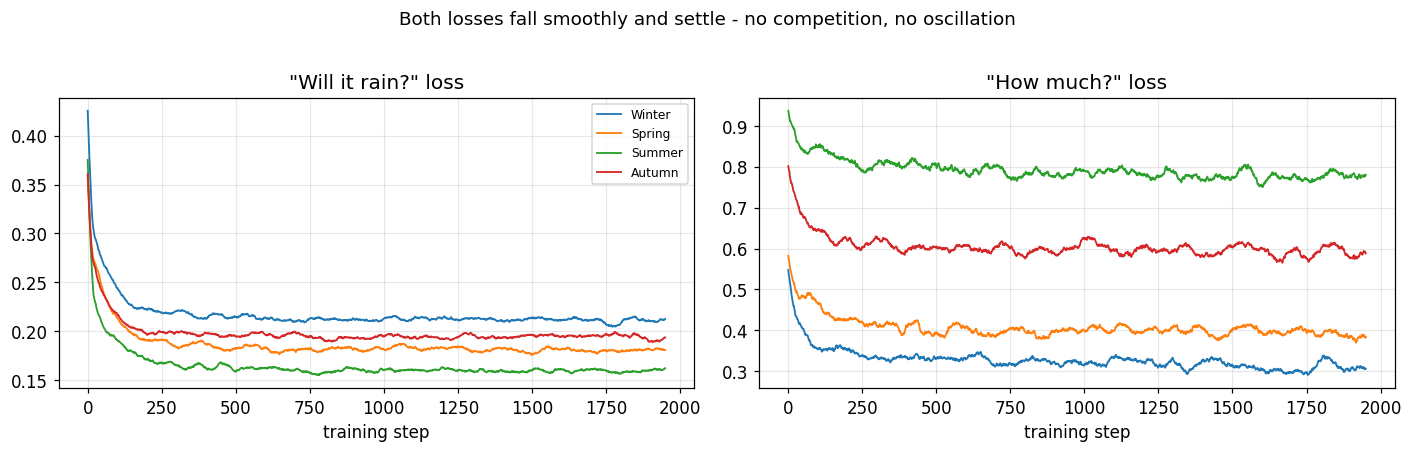

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for season in SEASONS:
    smooth = lambda v, k=50: np.convolve(v, np.ones(k)/k, mode='valid')
    ax[0].plot(smooth(HISTORY[season][:, 0]), lw=1.2, label=season.split(' ')[0])
    ax[1].plot(smooth(HISTORY[season][:, 1]), lw=1.2)
ax[0].set_title('"Will it rain?" loss'); ax[0].legend(fontsize=8)
ax[1].set_title('"How much?" loss')
for a in ax: a.set_xlabel('training step'); a.grid(alpha=0.3)
plt.suptitle('Both losses fall smoothly and settle - no competition, no oscillation', y=1.02, fontsize=12)
plt.tight_layout(); show(fig, '02_training')

### Compare this with the TimeGAN training curves

Both curves fall and flatten. That is all there is to check.

In the TimeGAN notebook the equivalent figure had to be read carefully: the discriminator loss falling to zero would have been *bad* news, and the whole thing oscillated around an uneasy truce. Here there is no truce to maintain, because there is nobody to fight. **If the loss goes down, the model is getting better — full stop.**

The "how much?" loss can be negative, which looks odd at first. It is a log-likelihood of a continuous quantity, so it is a density rather than a probability, and densities can exceed 1. Only the direction matters: down is better.

## 6. Generating rainfall, hour by hour

Generation is where an autoregressive model differs most from TimeGAN. TimeGAN produced a whole 96-hour window in one shot. This model builds the series **one hour at a time**, and each new hour is fed back in as input for the next:

1. ask the model for **p**, **m**, **s**;
2. toss a coin with probability **p** — does it rain?
3. if yes, draw the amount from the gamma with mean **m** and shape **s**;
4. feed that hour back in, and repeat.

Two practical points, both worth being explicit about:

**A warm-up.** We start the model from a dry state, which is an arbitrary choice, so the first hours are biased by it. We generate 24 extra hours at the front and throw them away, leaving the model in a state it has reached on its own.

**Nothing is calibrated.** In the TimeGAN notebook I had to impose the observed fraction of wet hours with a threshold. Here there is nothing to impose: the model outputs its own probability of rain, so the wet fraction is a **genuine prediction**. If it comes out right, that is a result rather than an assumption.

In [7]:
GAUGE = 0.1
def through_the_gauge(x):
    """What a 0.1 mm tipping bucket would have recorded. Applied to every generator."""
    return np.round(x/GAUGE)*GAUGE

def generate(season, n_windows, warmup=24, seed=0):
    """Roll the model forward hour by hour, feeding each new hour back in."""
    torch.manual_seed(seed)
    model = MODELS[season]
    hours = []
    x = torch.zeros(n_windows, 1, 2)        # start from a dry hour
    memory = None
    with torch.no_grad():
        for t in range(warmup + L):
            chance, z, memory = model(x, memory)
            is_wet = (torch.rand_like(chance[:, 0]) < chance[:, 0]).float()   # step 2: toss the coin
            depth  = amount_distribution(z[:, 0, :]).sample().clamp(0, 200)*is_wet   # step 3
            hours.append(depth)
            x = torch.stack([is_wet, torch.log1p(depth)/LOGMAX[season]], dim=-1).unsqueeze(1)
    out = torch.stack(hours, dim=1).numpy()[:, warmup:]                  # drop the warm-up
    return through_the_gauge(out)

AR = {s: generate(s, len(test_windows[s]), seed=SEED) for s in SEASONS}
for s in SEASONS:
    print(f'{s:14s}: wet hours {100*(AR[s]>0).mean():4.1f}% (observed {100*(test_windows[s]>0).mean():4.1f}%) '
          f'| rainfall {AR[s].mean()*24:.2f} mm/day (observed {test_windows[s].mean()*24:.2f}) '
          f'| heaviest hour {AR[s].max():5.1f} mm (observed {test_windows[s].max():.1f})')

Winter (DJF)  : wet hours  9.3% (observed 10.1%) | rainfall 1.50 mm/day (observed 1.59) | heaviest hour  13.0 mm (observed 10.8)
Spring (MAM)  : wet hours  6.6% (observed  8.4%) | rainfall 1.06 mm/day (observed 1.37) | heaviest hour   8.4 mm (observed 14.1)
Summer (JJA)  : wet hours  6.6% (observed  6.6%) | rainfall 1.85 mm/day (observed 1.63) | heaviest hour  35.9 mm (observed 48.5)
Autumn (SON)  : wet hours  8.5% (observed  8.9%) | rainfall 1.71 mm/day (observed 1.88) | heaviest hour  14.7 mm (observed 15.8)


## 6.5 Getting the extremes right

This section records the one part of the model that took more than a first attempt, because the reasoning matters more than the answer.

**The problem.** With a single gamma, the model reproduced the record well but could not reach the heaviest hours: **6.9 mm across an entire winter, against 10.8 mm observed**. For design rainfall, where the extremes are the whole point, that is the worst place to be wrong.

**First attempt — weight the large values more heavily.** This was suggested by Dr Li-Pen Wang, whose exact words were to give "more weight to the larger values' MSE". Written as a weight `1 + k·(depth/mean depth)` inside the loss, it produced this (winter):

| weight k | total rainfall | p90 | p99.9 | heaviest hour |
|---|---|---|---|---|
| *observed* | *1.59 mm/day* | *1.60* | *5.88* | *10.8* |
| 0 (no weighting) | 1.64 | 1.50 | 5.50 | 6.9 |
| 1 | **4.01** | 2.80 | 9.94 | 16.4 |
| 3 | **6.59** | 3.30 | 10.60 | 19.1 |
| 10 | **7.89** | 3.60 | 10.54 | 16.5 |

The tail does rise — and the water balance collapses with it. At k = 1 the model already produces **two and a half times too much rain**, and the 90th percentile overshoots as badly as the maximum undershot before.

The reason is a mismatch between two settings. Weighting large values works when a model predicts **a single number** and is scored by squared error: the prediction is pulled towards the peaks. This model predicts **a whole distribution** and is trained by likelihood, so reweighting does not sharpen the tail — it shifts the entire predicted distribution upwards. The suggestion identified the right problem; the mechanism does not transfer.

**Second attempt — change the distribution instead.** If the tail is too light, that is a statement about the *family* of distributions, not about the weights. Three families, same model, same training (winter):

| family | total rainfall | p90 | p99 | p99.9 | heaviest hour |
|---|---|---|---|---|---|
| *observed* | *1.59 mm/day* | *1.60* | *3.60* | *5.88* | *10.8* |
| one gamma | 1.64 | 1.50 | 3.30 | 5.50 | 6.9 |
| lognormal | 1.50 | 1.40 | 4.40 | 9.60 | 30.0 |
| **two gammas mixed** | 1.50 | **1.60** | **3.50** | 5.40 | **13.0** |

The lognormal overcorrects — a 30 mm hour in a London winter is not credible. The mixture lands the 90th percentile exactly, the 99th within 0.1 mm, and brings the heaviest hour to 13.0 mm against 10.8 observed. For comparison, **Bartlett–Lewis reaches 16.6 mm on the same measure**, so the mixture is now the closer of the two on the winter extreme.

It is not free: the wet fraction slips from 10.14 % to 9.29 % and total rainfall from 1.64 to 1.50 mm/day, both slightly further from the observations. That is the trade being made — a little accuracy in the body of the distribution, bought for a large gain in the tail.

*(Both tables come from winter-only experiments run separately, so that four seasons did not have to be retrained for each variant. The model in this notebook is the two-gamma mixture, and its tail behaviour across all four seasons is shown in Section 11.)*

## 7. The other three sources

The observations, the Bartlett–Lewis simulation and the TimeGAN output were all saved by the previous notebook, so we simply load them. Nothing is refitted or retrained here, which means the comparison in Section 10 is exactly the same measurement applied to one more generator.

In [8]:
saved = np.load(find('Claude/outputs/timegan_heathrow_v1/generated_rainfall.npz'))
OBS = {s: saved[f'obs_{s.split(" ")[0]}'] for s in SEASONS}
BL  = {s: saved[f'bl_{s.split(" ")[0]}']  for s in SEASONS}
GAN = {s: saved[f'gan_{s.split(" ")[0]}'] for s in SEASONS}

# safety check: the observations we just loaded must match the ones cut in Section 3
for s in SEASONS:
    assert OBS[s].shape == test_windows[s].shape and np.allclose(OBS[s], test_windows[s]), s
print('Loaded observations, Bartlett-Lewis and TimeGAN from the previous notebook.')
print('The observations match the windows cut in Section 3 exactly, so all four sources line up.')
SOURCES = [('Observed', OBS, '#1f77b4'), ('Bartlett–Lewis', BL, '#2ca02c'),
           ('TimeGAN (raw)', GAN, '#d62728'), ('Autoregressive', AR, '#9467bd')]

Loaded observations, Bartlett-Lewis and TimeGAN from the previous notebook.
The observations match the windows cut in Section 3 exactly, so all four sources line up.


## 8. First look

Sixteen days from each of the four sources. This is the same figure as the TimeGAN notebook, with one row added.

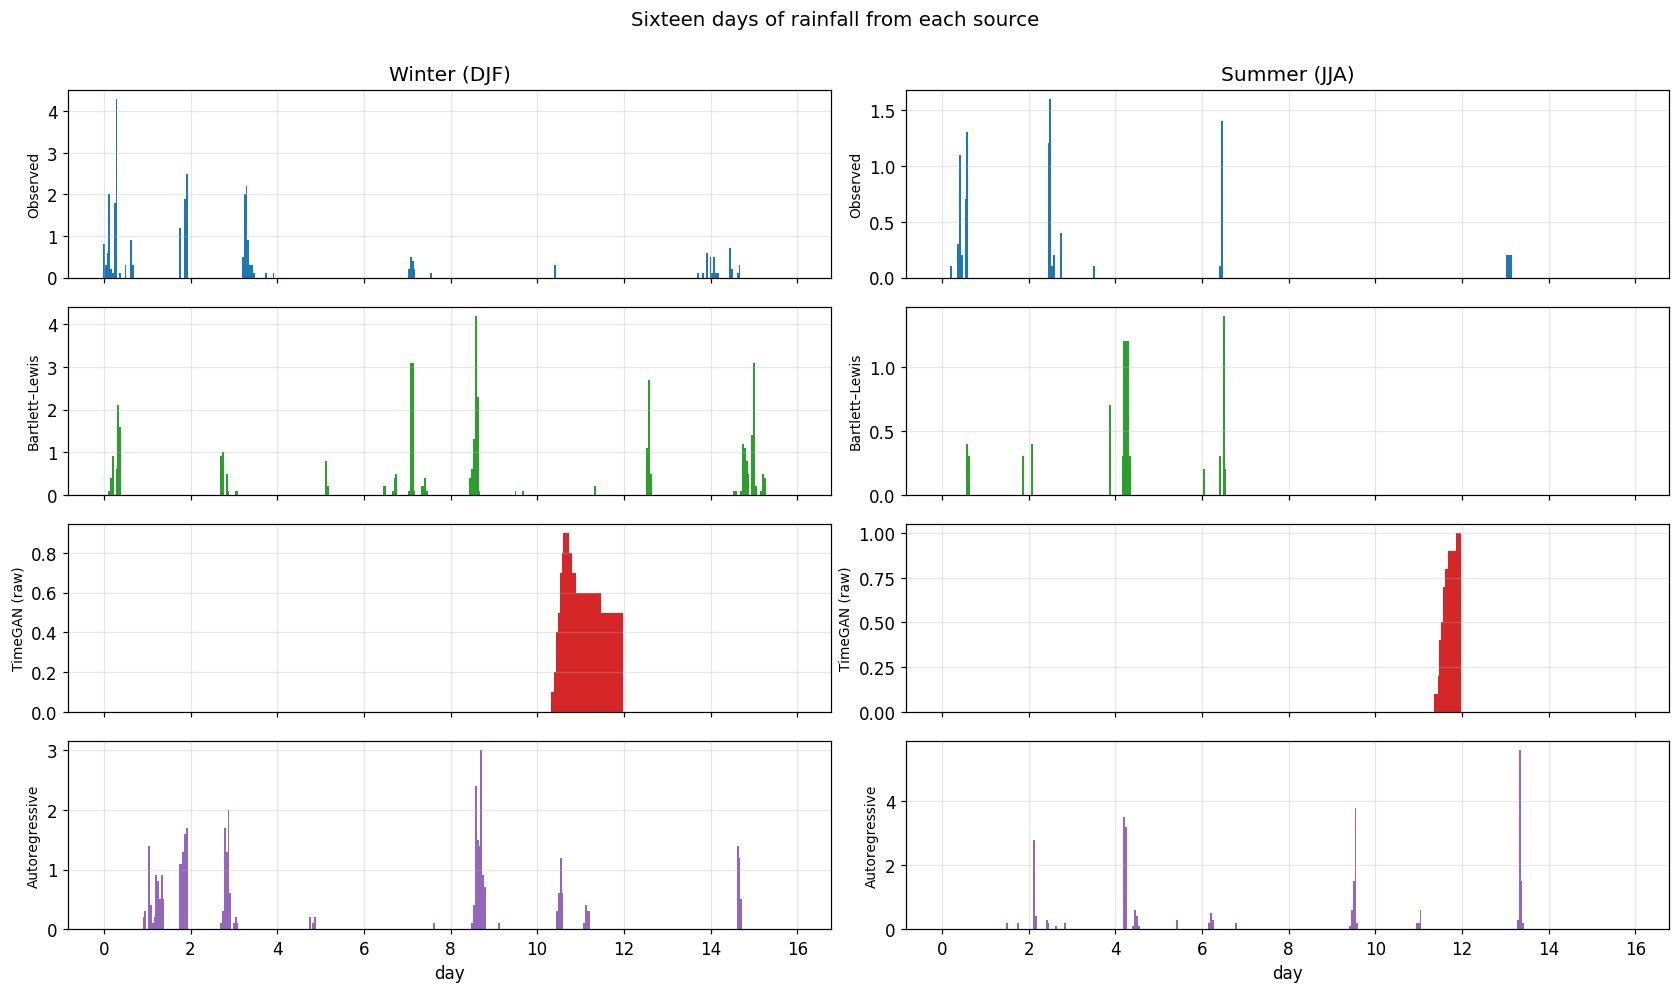

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(15.5, 9), sharex=True)
for col, season in enumerate(['Winter (DJF)', 'Summer (JJA)']):
    for row, (name, source, colour) in enumerate(SOURCES):
        stretch = np.concatenate(source[season][:4])
        axes[row, col].bar(np.arange(len(stretch))/24, stretch, width=1/24, color=colour)
        axes[row, col].set_ylabel(name, fontsize=9); axes[row, col].grid(alpha=0.3)
    axes[0, col].set_title(season)
axes[3, 0].set_xlabel('day'); axes[3, 1].set_xlabel('day')
plt.suptitle('Sixteen days of rainfall from each source', y=1.0, fontsize=13)
plt.tight_layout(); show(fig, '03_eyeball')

## 9. The collapse check

The same three questions as the TimeGAN notebook, because a new model deserves the same suspicion as the old one. A model that cannot collapse *in theory* still has to be checked *in practice*.

- **is any hour of the window special?** flat is healthy;
- **are two generated windows different?** near zero is healthy, near one is collapse;
- **is the rain shared out realistically?** a spike at zero means all-or-nothing windows.

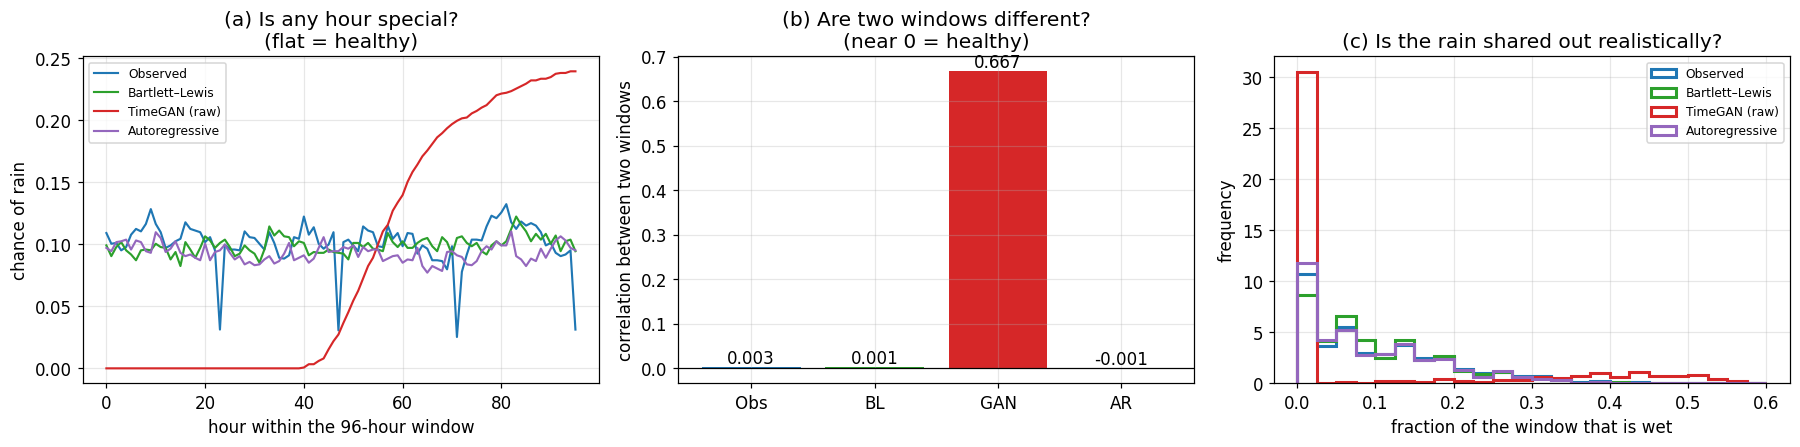

Winter diagnostics:
  Observed        chance of rain by hour 0.025-0.132 | correlation between two windows +0.003 | completely dry windows  14%
  Bartlett–Lewis  chance of rain by hour 0.082-0.122 | correlation between two windows +0.001 | completely dry windows  13%
  TimeGAN (raw)   chance of rain by hour 0.000-0.239 | correlation between two windows +0.667 | completely dry windows  76%
  Autoregressive  chance of rain by hour 0.077-0.110 | correlation between two windows -0.001 | completely dry windows  11%


In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.2))
def window_similarity(w, n=200):
    c = np.corrcoef(w[:n]); return float(np.nanmean(c[np.triu_indices(n, 1)]))

for name, source, colour in SOURCES:
    ax[0].plot((source['Winter (DJF)'] > 0).mean(axis=0), color=colour, lw=1.4, label=name)
ax[0].set_xlabel('hour within the 96-hour window'); ax[0].set_ylabel('chance of rain')
ax[0].set_title('(a) Is any hour special?\n(flat = healthy)'); ax[0].legend(fontsize=8)

similarity = [window_similarity(source['Winter (DJF)']) for _, source, _ in SOURCES]
ax[1].bar(['Obs', 'BL', 'GAN', 'AR'], similarity, color=[c for _, _, c in SOURCES])
ax[1].axhline(0, color='k', lw=0.8); ax[1].set_ylabel('correlation between two windows')
ax[1].set_title('(b) Are two windows different?\n(near 0 = healthy)')
for i, v in enumerate(similarity): ax[1].text(i, v, f'{v:.3f}', ha='center', va='bottom')

for name, source, colour in SOURCES:
    ax[2].hist((source['Winter (DJF)'] > 0).mean(axis=1), bins=np.linspace(0, 0.6, 25),
               density=True, histtype='step', lw=2, color=colour, label=name)
ax[2].set_xlabel('fraction of the window that is wet'); ax[2].set_ylabel('frequency')
ax[2].set_title('(c) Is the rain shared out realistically?'); ax[2].legend(fontsize=8)
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); show(fig, '04_collapse_check')

print('Winter diagnostics:')
for name, source, _ in SOURCES:
    w = source['Winter (DJF)']; p = (w > 0).mean(axis=0); f = (w > 0).mean(axis=1)
    print(f'  {name:15s} chance of rain by hour {p.min():.3f}-{p.max():.3f} | '
          f'correlation between two windows {window_similarity(w):+.3f} | '
          f'completely dry windows {100*(f == 0).mean():3.0f}%')

## 10. The scoreboard

The same five statistics, the same three timescales, the same four seasons as everywhere else in this project — now with three generators to compare.

In [11]:
def five_statistics(windows, hours):
    """The five statistics of these windows, aggregated to blocks of `hours`."""
    n = windows.shape[1]//hours
    blocks = windows[:, :n*hours].reshape(-1, hours).sum(axis=1)
    m, v = blocks.mean(), blocks.var()
    grid = blocks.reshape(len(windows), n)              # lag-1 pairs stay inside a window
    a, b = grid[:, :-1].ravel(), grid[:, 1:].ravel()
    return {'mean': m, 'variance': v, 'autocorrelation': ((a-m)*(b-m)).mean()/v,
            'skewness': scipy_skew(blocks), 'proportion dry': (blocks < 1e-9).mean()}

STATS = ['mean', 'variance', 'autocorrelation', 'skewness', 'proportion dry']
rows = []
for name, source, _ in SOURCES[1:]:                     # skip the observations themselves
    row = {'Generator': name}
    for stat in STATS:
        errors = [abs(five_statistics(source[s], h)[stat] - five_statistics(OBS[s], h)[stat])
                  / abs(five_statistics(OBS[s], h)[stat]) * 100
                  for s in SEASONS for h in [1, 6, 24]
                  if abs(five_statistics(OBS[s], h)[stat]) > 1e-12]
        row[stat] = round(float(np.nanmean(errors)), 1)
    rows.append(row)
scoreboard = pd.DataFrame(rows).set_index('Generator')
scoreboard.to_csv(FIG_DIR/'scoreboard.csv')
print('Average error against the observations (%), over four seasons and three timescales:')
scoreboard

Average error against the observations (%), over four seasons and three timescales:


,mean,variance,autocorrelation,skewness,proportion dry
Generator,,,,,
Bartlett–Lewis,2.5,15.3,13.2,15.7,4.2
TimeGAN (raw),29.4,49.2,192.1,40.8,29.3
Autoregressive,12.8,15.1,9.9,11.3,2.4


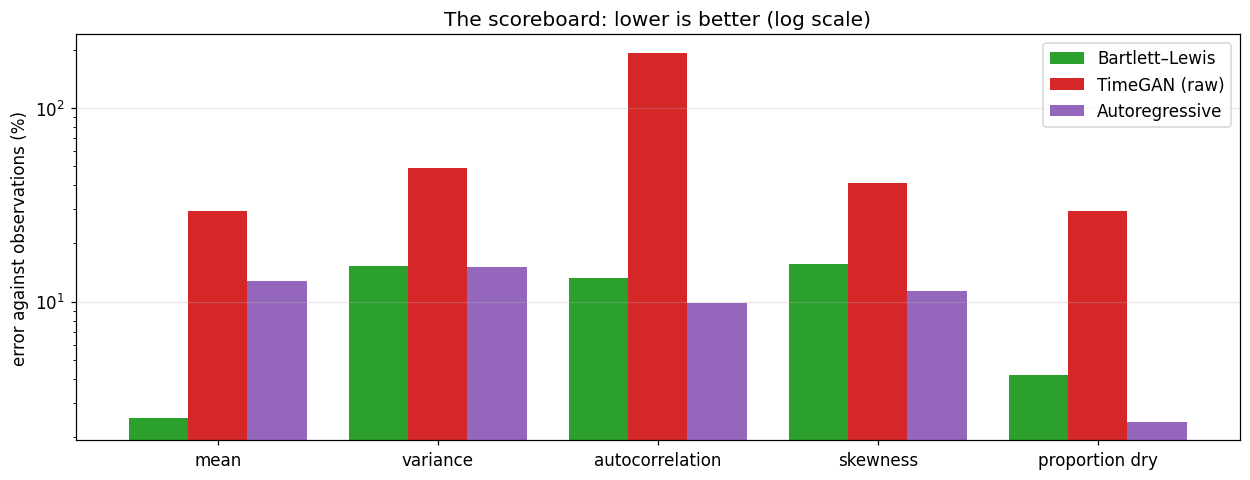

In [12]:
fig, ax = plt.subplots(figsize=(11.5, 4.5))
x = np.arange(len(STATS)); width = 0.27
for i, (name, _, colour) in enumerate(SOURCES[1:]):
    ax.bar(x + (i-1)*width, scoreboard.loc[name], width, color=colour, label=name)
ax.set_xticks(x); ax.set_xticklabels(STATS)
ax.set_ylabel('error against observations (%)'); ax.set_yscale('log')
ax.set_title('The scoreboard: lower is better (log scale)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); show(fig, '05_scoreboard')

## 11. Three closer looks

The scoreboard says how close each generator lands. These three say **why** — and they include the property TimeGAN failed at most spectacularly.

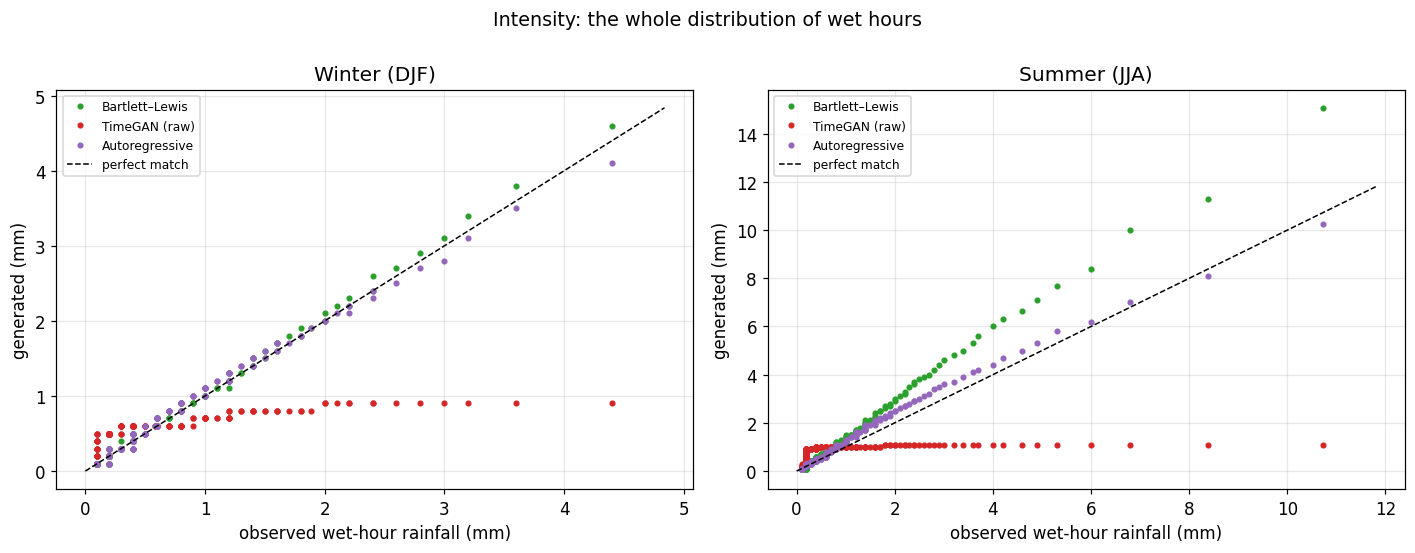

Heaviest hour produced, winter:
  Observed         10.8 mm
  Bartlett–Lewis   16.6 mm
  TimeGAN (raw)     0.9 mm
  Autoregressive   13.0 mm


In [13]:
# --- 11.1 intensity: can each generator produce heavy rain at all? ---
quantiles = np.linspace(1, 99.5, 200)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for axi, season in zip(ax, ['Winter (DJF)', 'Summer (JJA)']):
    obs_q = np.percentile(OBS[season][OBS[season] > 0], quantiles)
    for name, source, colour in SOURCES[1:]:
        w = source[season][source[season] > 0]
        if len(w) == 0:
            print(f'{name}: no wet hours in {season}'); continue
        axi.plot(obs_q, np.percentile(w, quantiles), 'o', ms=3, color=colour, label=name)
    top = obs_q.max()*1.1
    axi.plot([0, top], [0, top], 'k--', lw=1, label='perfect match')
    axi.set_xlabel('observed wet-hour rainfall (mm)'); axi.set_ylabel('generated (mm)')
    axi.set_title(season); axi.grid(alpha=0.3); axi.legend(fontsize=8)
plt.suptitle('Intensity: the whole distribution of wet hours', y=1.0, fontsize=12.5)
plt.tight_layout(); show(fig, '06_intensity')

print('Heaviest hour produced, winter:')
for name, source, _ in SOURCES:
    print(f'  {name:15s} {source["Winter (DJF)"].max():5.1f} mm')

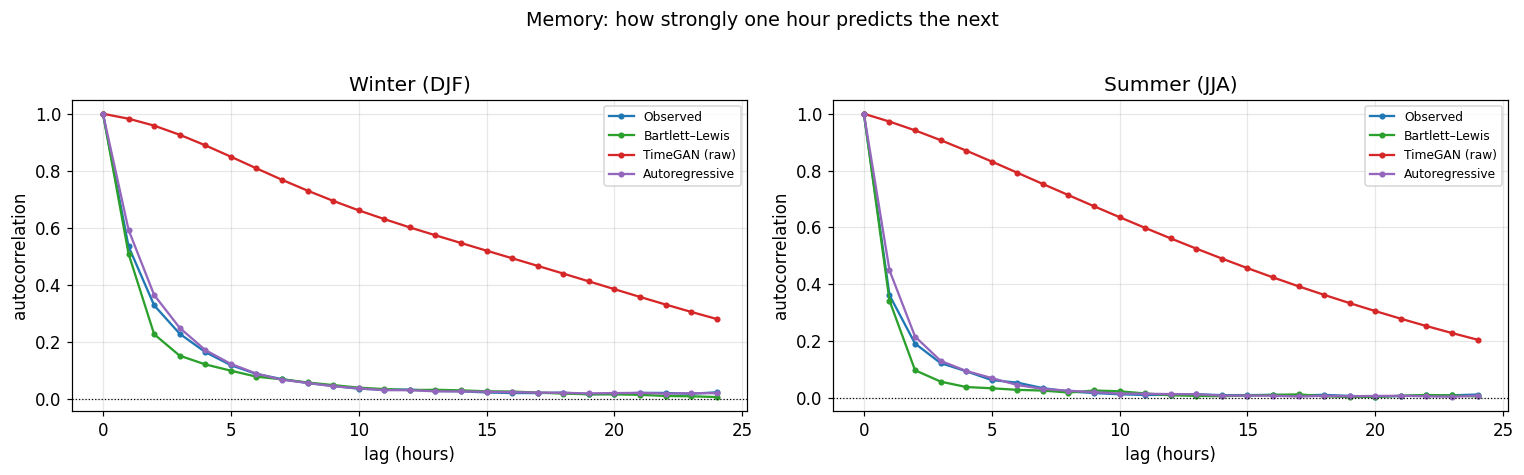

In [14]:
# --- 11.2 memory: does rain follow rain? ---
def autocorrelation_curve(windows, max_lag=24):
    x = windows - windows.mean(); denominator = (x*x).sum()
    return [1.0] + [float((x[:, :-k]*x[:, k:]).sum()/denominator) for k in range(1, max_lag+1)]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for axi, season in zip(ax, ['Winter (DJF)', 'Summer (JJA)']):
    for name, source, colour in SOURCES:
        axi.plot(autocorrelation_curve(source[season]), 'o-', ms=3, color=colour, label=name)
    axi.axhline(0, color='k', lw=0.8, ls=':')
    axi.set_xlabel('lag (hours)'); axi.set_ylabel('autocorrelation'); axi.set_title(season)
    axi.grid(alpha=0.3); axi.legend(fontsize=8)
plt.suptitle('Memory: how strongly one hour predicts the next', y=1.02, fontsize=12.5)
plt.tight_layout(); show(fig, '07_memory')

In [15]:
# --- 11.3 storms: the test nobody was fitted or trained on ---
def count_storms(windows, gap=6):
    """Storm events inside a window: wet periods separated by at least `gap` dry hours."""
    durations = []
    for w in windows:
        wet = w > 0; i = 0
        while i < len(w):
            if wet[i]:
                last, dry, j = i, 0, i
                while j < len(w):
                    if wet[j]: last, dry = j, 0
                    else:
                        dry += 1
                        if dry >= gap: break
                    j += 1
                durations.append(last - i + 1); i = j + 1
            else: i += 1
    return np.array(durations)

rows = []
for name, source, _ in SOURCES:
    storms = np.concatenate([count_storms(source[s]) for s in SEASONS])
    total = sum(len(source[s]) for s in SEASONS)
    rows.append({'Source': name, 'storms per 4-day window': round(len(storms)/total, 2),
                 'mean storm duration (h)': round(float(storms.mean()), 1)})
storm_table = pd.DataFrame(rows).set_index('Source')
storm_table.to_csv(FIG_DIR/'storms.csv')
print('Storm events — used in neither the Bartlett-Lewis fitting nor any network training:')
storm_table

Storm events — used in neither the Bartlett-Lewis fitting nor any network training:


,storms per 4-day window,mean storm duration (h)
Source,,
Observed,1.94,5.7
Bartlett–Lewis,1.65,6.3
TimeGAN (raw),0.20,32.5
Autoregressive,1.88,5.4


## 12. Conclusions

*(Written after looking at the results, not before.)*

### It does not collapse

The check that sank TimeGAN is clean, and it was clean on the first attempt — there was no configuration to search for:

| winter diagnostic | Observed | Bartlett–Lewis | TimeGAN | **Autoregressive** |
|---|---|---|---|---|
| correlation between two generated windows | 0.003 | 0.001 | 0.667 | **−0.001** |
| chance of rain across the 96 positions | 0.025–0.132 | 0.082–0.122 | 0.000–0.239 | **0.077–0.110** |
| completely dry windows | 14 % | 13 % | 76 % | **11 %** |

### The scoreboard

| | mean | variance | autocorrelation | skewness | proportion dry |
|---|---|---|---|---|---|
| Bartlett–Lewis | **2.5** | 15.3 | 13.2 | 15.7 | 4.2 |
| TimeGAN (raw) | 29.4 | 49.2 | 192.1 | 40.8 | 29.3 |
| Autoregressive | 12.8 | **15.1** | **9.9** | **11.3** | **2.4** |

The neural model takes four of the five columns, but the one it loses it loses badly: a 12.8 % error on the mean against 2.5 % for Bartlett–Lewis. That single number deserves more attention than the four wins.

The free test still favours the network. Storm events were used in neither the Bartlett–Lewis fitting nor any training: real four-day windows contain 1.94 storms of 5.7 hours, Bartlett–Lewis produces 1.65 of 6.3 hours, and this model 1.88 of 5.4 hours.

### The trade that was made, and whether it was worth it

Section 6.5 replaced a single gamma with a mixture of two, to fix the extremes. Setting the two versions side by side shows what that actually cost:

| | mean | variance | autocorrelation | skewness | proportion dry | winter max | summer max |
|---|---|---|---|---|---|---|---|
| *observed* | | | | | | *10.8* | *48.5* |
| one gamma | **4.9** | **9.7** | 17.7 | 13.7 | **1.3** | 6.9 | 18.5 |
| two gammas | 12.8 | 15.1 | **9.9** | **11.3** | 2.4 | **13.0** | **35.9** |

The extremes improve a great deal — the summer maximum nearly doubles and lands close to the 37.4 mm of Bartlett–Lewis — and three of the five statistics get worse. This is a genuine trade, not an upgrade, and which version is preferable depends on what the generator is for. For design rainfall the extremes dominate, which is why the mixture is the version kept here; for a water-balance study the single gamma would be the better choice.

Season by season, the cost is not spread evenly:

| total rainfall (mm/day) | observed | generated |
|---|---|---|
| Winter | 1.59 | 1.50 |
| **Spring** | **1.37** | **1.06** |
| Summer | 1.63 | 1.85 |
| Autumn | 1.88 | 1.71 |

Three seasons sit within about 10 %; spring alone is 23 % short, and it produces 6.6 % wet hours against 8.4 % observed. That one season carries most of the 12.8 % mean error. With a single seed I cannot say whether it is a property of the mixture or an unlucky training run, and finding out is the first thing to do next.

### What this says about the comparison as a whole

Ordering the three generators by how much was *told* to them rather than learned:

| | what it was given | result |
|---|---|---|
| Bartlett–Lewis | a full mechanism: storms arrive, contain cells, cells rain | works |
| Autoregressive | only the *shape*: rain is an occurrence times a mixture of two amounts | works |
| TimeGAN | nothing at all | collapses |

TimeGAN's failure was never evidence that deep learning cannot generate rainfall. Training a separate experiment on the wet/dry series alone — every positive value set to 1, as suggested by Prof. Onof — the same collapse appeared, with wet spells four times too long and a window-to-window correlation of 0.697. Removing the intensity problem entirely did not help, so the fault lies in adversarial training rather than in the zeros.

Replace the competition with maximum likelihood, supply the single structural fact that rainfall is an occurrence-and-amount process, and a network of **3 654 weights trained in five minutes** is competitive with a model that took decades of hydrological theory to develop. The prior knowledge that must be supplied is far less than the Bartlett–Lewis mechanism — but it is not zero, and locating that boundary is the real subject of this comparison.

### Caveats

**One seed.** Every number here comes from a single training run and a single generation. The differences between this model and Bartlett–Lewis are small enough on most statistics that an ensemble is needed before ranking them, and the spring anomaly above may not survive one.

**No held-out period.** The measurement windows come from the same years as the training windows, so this shows that the model reproduces the statistics of the record it was trained on, not that it generalises to unseen years. That matters more for 3 654 weights than for six parameters per month. Training on 1949–2000 and testing on 2001–2022, with Bartlett–Lewis recalibrated on the same reduced period, is the obvious next step.

In [16]:
import os
np.savez_compressed(FIG_DIR/'generated_rainfall.npz',
                    **{f'{k}_{s.split(" ")[0]}': v[s] for k, v in
                       [('obs', OBS), ('bl', BL), ('gan', GAN), ('ar', AR)] for s in SEASONS})
print('Figures and tables saved to', FIG_DIR.resolve(), ':')
for f in sorted(os.listdir(FIG_DIR)): print('  ', f)
print('\nNotebook complete — autoregressive rainfall generator at Heathrow.')

Figures and tables saved to C:\Users\rajab\OneDrive\Bureau\DISSERTATION\Claude\outputs\autoregressive_heathrow_v1 :
   01_gamma.png
   02_training.png
   03_eyeball.png
   04_collapse_check.png
   05_scoreboard.png
   06_intensity.png
   07_memory.png
   generated_rainfall.npz
   scoreboard.csv
   storms.csv

Notebook complete — autoregressive rainfall generator at Heathrow.
